# BTCT TUẦN 2 – NHÓM 33 – FULL DATASET

**Thay đổi so với bản 500 ảnh:**
- Chạy trên **toàn bộ dataset** (~34,250 ảnh)
- Dùng **FAISS IndexFlatIP** thay `torch.mm` brute-force (tránh OOM, nhanh hơn 10-20×)
- Trích xuất embedding theo **batch** với `tqdm` tiến trình
- Đánh giá trên **1,000 query ngẫu nhiên** (đại diện, không chậm quá)

---
## CELL 1: IMPORT THƯ VIỆN

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, warnings
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('✅ Import thư viện thành công!')
print(f'   PyTorch : {torch.__version__}')
print(f'   FAISS   : {faiss.__version__}')
print(f'   Device  : {DEVICE}')

✅ Import thư viện thành công!
   PyTorch : 2.12.0+cu126
   FAISS   : 1.13.2
   Device  : cuda


---
## CELL 2: ĐƯỜNG DẪN & HẰNG SỐ

In [2]:
# ── Đường dẫn ─────────────────────────────────────────────
DATA_DIR  = r'E:\study\DoAnPython\code\DoAnPython\project\data\raw'   # ← chỉnh nếu cần
CSV_PATH  = os.path.join(DATA_DIR, 'train.csv')
IMAGE_DIR = os.path.join(DATA_DIR, 'train_images')

PROCESSED = '../data/processed/'
RESULTS   = '../results/'
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(RESULTS,   exist_ok=True)

# ── Siêu tham số ──────────────────────────────────────────
BATCH_SIZE   = 64      # giảm xuống 32 nếu RAM GPU < 6 GB
IMG_SIZE     = 224
EMBED_DIM    = 2048    # output pool5 ResNet50
TOP_K        = 10
N_QUERY      = 5000   # số query dùng để tính metric (đại diện toàn bộ)
EMBED_FILE   = os.path.join(PROCESSED, 'resnet50_full_embeddings.npy')

for p in [CSV_PATH, IMAGE_DIR]:
    tag = '✅' if os.path.exists(p) else '❌ KHÔNG TÌM THẤY'
    print(f'{tag}  {p}')

✅  E:\study\DoAnPython\code\DoAnPython\project\data\raw\train.csv
✅  E:\study\DoAnPython\code\DoAnPython\project\data\raw\train_images


---
## CELL 3: ĐỌC VÀ XEM THÔNG TIN CƠ BẢN DATASET

In [3]:
df = pd.read_csv(CSV_PATH)

print('THÔNG TIN CƠ BẢN DATASET')
print(f'  Tên bộ dữ liệu   : Shopee – Price Match Guarantee')
print(f'  Số dòng (ảnh)    : {df.shape[0]:,}')
print(f'  Số cột           : {df.shape[1]}')
print(f'  Tên các cột      : {list(df.columns)}')
print()

label_counts = df['label_group'].value_counts()
print('Thống kê label_group:')
print(f'  Tổng số nhóm           : {label_counts.shape[0]:,}')
print(f'  Số ảnh TB mỗi nhóm     : {label_counts.mean():.2f}')
print(f'  Nhóm ít ảnh nhất       : {label_counts.min()} ảnh')
print(f'  Nhóm nhiều ảnh nhất    : {label_counts.max()} ảnh')
print(f'  Nhóm có đúng 2 ảnh     : {(label_counts == 2).sum():,} nhóm')

df.head(3)

THÔNG TIN CƠ BẢN DATASET
  Tên bộ dữ liệu   : Shopee – Price Match Guarantee
  Số dòng (ảnh)    : 34,250
  Số cột           : 5
  Tên các cột      : ['posting_id', 'image', 'image_phash', 'title', 'label_group']

Thống kê label_group:
  Tổng số nhóm           : 11,014
  Số ảnh TB mỗi nhóm     : 3.11
  Nhóm ít ảnh nhất       : 2 ảnh
  Nhóm nhiều ảnh nhất    : 51 ảnh
  Nhóm có đúng 2 ảnh     : 6,979 nhóm


,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891


---
## CELL 4: KIỂM TRA DỮ LIỆU THIẾU VÀ TRÙNG LẶP

In [4]:
print('GIÁ TRỊ THIẾU (ô trống)')
print(df.isnull().sum())
print()
print('DÒNG TRÙNG LẶP')
print(f'Số dòng bị trùng: {df.duplicated().sum()}')

GIÁ TRỊ THIẾU (ô trống)
posting_id     0
image          0
image_phash    0
title          0
label_group    0
dtype: int64

DÒNG TRÙNG LẶP
Số dòng bị trùng: 0


---
## CELL 5: THỐNG KÊ LABEL_GROUP

In [5]:
so_anh_moi_nhom = df['label_group'].value_counts()

print('=== THỐNG KÊ LABEL_GROUP ===')
print(f'Tổng số nhóm sản phẩm      : {so_anh_moi_nhom.shape[0]:,}')
print(f'Ảnh ít nhất trong 1 nhóm   : {so_anh_moi_nhom.min()} ảnh')
print(f'Ảnh nhiều nhất trong 1 nhóm: {so_anh_moi_nhom.max()} ảnh')
print(f'Trung bình số ảnh / nhóm   : {so_anh_moi_nhom.mean():.2f} ảnh')
print(f'Nhóm có đúng 2 ảnh         : {(so_anh_moi_nhom == 2).sum():,} nhóm '
      f'({(so_anh_moi_nhom == 2).sum() / so_anh_moi_nhom.shape[0] * 100:.1f}%)')
print(f'Nhóm có trên 10 ảnh        : {(so_anh_moi_nhom > 10).sum():,} nhóm '
      f'({(so_anh_moi_nhom > 10).sum() / so_anh_moi_nhom.shape[0] * 100:.1f}%)')

=== THỐNG KÊ LABEL_GROUP ===
Tổng số nhóm sản phẩm      : 11,014
Ảnh ít nhất trong 1 nhóm   : 2 ảnh
Ảnh nhiều nhất trong 1 nhóm: 51 ảnh
Trung bình số ảnh / nhóm   : 3.11 ảnh
Nhóm có đúng 2 ảnh         : 6,979 nhóm (63.4%)
Nhóm có trên 10 ảnh        : 233 nhóm (2.1%)


---
## CELL 6: BIỂU ĐỒ PHÂN BỐ DỮ LIỆU

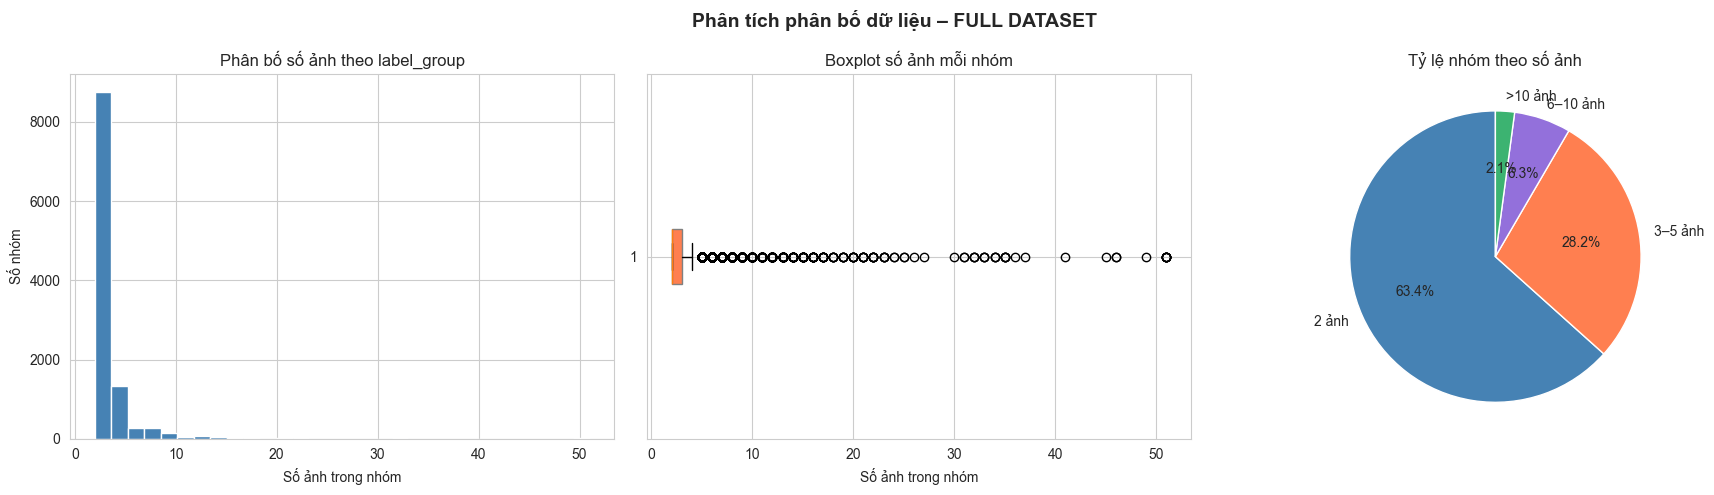

Nhận xét: 63.4% nhóm chỉ có 2 ảnh → thách thức cho Recall@K.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phân tích phân bố dữ liệu – FULL DATASET', fontsize=14, fontweight='bold')

# ── Biểu đồ 1: Histogram ────────────────────────────────
axes[0].hist(so_anh_moi_nhom.values, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Phân bố số ảnh theo label_group')
axes[0].set_xlabel('Số ảnh trong nhóm')
axes[0].set_ylabel('Số nhóm')

# ── Biểu đồ 2: Boxplot ──────────────────────────────────
axes[1].boxplot(so_anh_moi_nhom.values, vert=False, patch_artist=True,
                boxprops=dict(facecolor='coral', color='gray'))
axes[1].set_title('Boxplot số ảnh mỗi nhóm')
axes[1].set_xlabel('Số ảnh trong nhóm')

# ── Biểu đồ 3: Pie chart ────────────────────────────────
phan_loai = pd.cut(so_anh_moi_nhom,
                   bins=[1, 2, 5, 10, 999],
                   labels=['2 ảnh', '3–5 ảnh', '6–10 ảnh', '>10 ảnh'])
ty_le = phan_loai.value_counts()
axes[2].pie(ty_le.values, labels=ty_le.index, autopct='%1.1f%%',
            colors=['steelblue', 'coral', 'mediumpurple', 'mediumseagreen'],
            startangle=90)
axes[2].set_title('Tỷ lệ nhóm theo số ảnh')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'bieu_do_phan_bo_full.png'), dpi=150, bbox_inches='tight')
plt.show()

nhom_2_anh = (so_anh_moi_nhom == 2).sum()
print(f'Nhận xét: {nhom_2_anh / so_anh_moi_nhom.shape[0]*100:.1f}% nhóm chỉ có 2 ảnh → thách thức cho Recall@K.')

---
## CELL 7: XÂY DỰNG CANDIDATE_DF TOÀN BỘ DATASET

> **Khác bản 500 ảnh:** Giữ **toàn bộ ảnh** — không sample, không giới hạn nhóm.  
> Chỉ loại bỏ ảnh không tồn tại trên disk.

In [7]:
# Giữ toàn bộ ảnh, chỉ lọc nhóm có >= 2 ảnh (cần ít nhất 1 ground-truth)
valid_groups = df['label_group'].value_counts()
valid_groups = valid_groups[valid_groups >= 2].index

candidate_df = df[df['label_group'].isin(valid_groups)].copy().reset_index(drop=True)
candidate_df['image_path'] = candidate_df['image'].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

# Kiểm tra ảnh tồn tại (chạy nhanh qua os.path.exists)
print('Đang kiểm tra file ảnh trên disk...')
candidate_df['exists'] = candidate_df['image_path'].apply(os.path.exists)
n_missing = (~candidate_df['exists']).sum()
if n_missing > 0:
    print(f'⚠️  {n_missing} ảnh không tìm thấy – bị bỏ qua')
candidate_df = candidate_df[candidate_df['exists']].drop(columns='exists').reset_index(drop=True)

# Ground-truth: tập posting_id cùng label_group
label2ids = candidate_df.groupby('label_group')['posting_id'].apply(set).to_dict()
candidate_df['gt_matches'] = candidate_df['label_group'].map(label2ids)

print(f'\n✅ candidate_df FULL:')
print(f'   Tổng số ảnh        : {len(candidate_df):,}')
print(f'   Unique label groups: {candidate_df["label_group"].nunique():,}')
candidate_df.head(3)

Đang kiểm tra file ảnh trên disk...

✅ candidate_df FULL:
   Tổng số ảnh        : 34,250
   Unique label groups: 11,014


,posting_id,image,image_phash,title,label_group,image_path,gt_matches
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794,E:\study\DoAnPython\code\DoAnPython\project\da...,"{train_2278313361, train_129225211}"
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045,E:\study\DoAnPython\code\DoAnPython\project\da...,"{train_3423213080, train_3386243561}"
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891,E:\study\DoAnPython\code\DoAnPython\project\da...,"{train_2288590299, train_3803689425}"


---
## CELL 8: TIỀN XỬ LÝ ẢNH – DATASET & DATALOADER

In [8]:
class ShopeeDataset(Dataset):
    TRANSFORM = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225],
        ),
    ])

    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert('RGB')
        except Exception:
            img = Image.fromarray(
                np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            )
        return self.TRANSFORM(img), idx


# Test nhanh
_ds = ShopeeDataset(candidate_df['image_path'].tolist())
_t, _i = _ds[0]
print(f'✅ Dataset OK – tensor shape: {_t.shape}, dtype: {_t.dtype}')
print(f'   Tổng ảnh sẽ xử lý: {len(_ds):,}')

✅ Dataset OK – tensor shape: torch.Size([3, 224, 224]), dtype: torch.float32
   Tổng ảnh sẽ xử lý: 34,250


---
## CELL 9: LOAD RESNET50 VÀ TRÍCH XUẤT EMBEDDING TOÀN BỘ

> **Thời gian ước tính:**  
> - CPU: ~40–60 phút với 34K ảnh  
> - GPU (T4/RTX): ~5–10 phút  
> 
> Embedding được **lưu xuống disk** sau khi trích xuất.  
> Lần chạy tiếp theo sẽ **load từ file**, không cần chạy lại.

In [9]:
# ── Load ResNet50 ────────────────────────────────────────
base_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
# Bỏ lớp FC → output 2048-d từ GlobalAveragePool
feature_extractor = nn.Sequential(*list(base_model.children())[:-1])
feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()

total_params = sum(p.numel() for p in feature_extractor.parameters())
print(f'✅ ResNet50 loaded – {total_params/1e6:.1f}M params, eval mode, device={DEVICE}')

✅ ResNet50 loaded – 23.5M params, eval mode, device=cuda


In [10]:
@torch.no_grad()
def extract_all_embeddings(model, image_paths, batch_size=BATCH_SIZE, device=DEVICE):
    """
    Trích xuất L2-normalized embedding cho toàn bộ dataset.
    Lưu tiến trình ra EMBED_FILE để không phải chạy lại.
    """
    N   = len(image_paths)
    emb = np.zeros((N, EMBED_DIM), dtype=np.float32)

    dataset = ShopeeDataset(image_paths)
    loader  = DataLoader(
        dataset, batch_size=batch_size,
        shuffle=False,
        num_workers=0 if device == 'cuda' else 2,
        pin_memory=(device == 'cuda'),
    )

    for batch_imgs, batch_idxs in tqdm(loader, desc='Trích xuất embedding', unit='batch'):
        batch_imgs = batch_imgs.to(device)
        feats = model(batch_imgs).squeeze(-1).squeeze(-1)   # (B, 2048)
        feats = feats.cpu().numpy().astype(np.float32)
        # L2 normalize
        norms = np.linalg.norm(feats, axis=1, keepdims=True) + 1e-10
        feats /= norms
        emb[batch_idxs.numpy()] = feats

    return emb


# ── Cache: load nếu đã trích xuất rồi ───────────────────
if os.path.exists(EMBED_FILE):
    print(f'📂 Tìm thấy file cache → đang load...')
    all_embeddings = np.load(EMBED_FILE)
    print(f'✅ Load xong – shape: {all_embeddings.shape}')
else:
    print(f'🚀 Bắt đầu trích xuất embedding ({len(candidate_df):,} ảnh)...')
    t0 = time.time()
    all_embeddings = extract_all_embeddings(
        feature_extractor,
        candidate_df['image_path'].tolist(),
    )
    t_elapsed = time.time() - t0
    np.save(EMBED_FILE, all_embeddings)
    print(f'\n✅ Xong – shape: {all_embeddings.shape}')
    print(f'   Thời gian    : {t_elapsed/60:.1f} phút')
    print(f'   Đã lưu → {EMBED_FILE}')

print(f'   Norm check   : {np.linalg.norm(all_embeddings, axis=1).mean():.4f} (≈ 1.0 là đúng)')

🚀 Bắt đầu trích xuất embedding (34,250 ảnh)...


Trích xuất embedding:   0%|          | 0/536 [00:00<?, ?batch/s]


✅ Xong – shape: (34250, 2048)
   Thời gian    : 4.9 phút
   Đã lưu → ../data/processed/resnet50_full_embeddings.npy
   Norm check   : 1.0000 (≈ 1.0 là đúng)


---
## CELL 10: XÂY DỰNG FAISS INDEX

Dùng `IndexFlatIP` (exact inner product = cosine khi đã L2-normalize).  
Với ~34K vector 2048-d, index vừa trong RAM (~270 MB).

In [11]:
d     = all_embeddings.shape[1]          # 2048
index = faiss.IndexFlatIP(d)
index.add(all_embeddings)                # thêm toàn bộ vector

print(f'✅ FAISS IndexFlatIP xây xong')
print(f'   Số vectors : {index.ntotal:,}')
print(f'   Chiều      : {d}')
print(f'   RAM ước tính: ~{index.ntotal * d * 4 / 1024**2:.0f} MB')

✅ FAISS IndexFlatIP xây xong
   Số vectors : 34,250
   Chiều      : 2048
   RAM ước tính: ~268 MB


---
## CELL 11: TÍNH PRECISION@K, RECALL@K, mAP TRÊN FULL DATASET

In [12]:
# ── Hàm metric ───────────────────────────────────────────
def average_precision(retrieved_ids, gt_set):
    """AP cho 1 query. gt_set đã loại posting_id của chính query."""
    if not gt_set:
        return 0.0
    ap, hits = 0.0, 0
    for rank, rid in enumerate(retrieved_ids, 1):
        if rid in gt_set:
            hits += 1
            ap   += hits / rank
    return ap / len(gt_set)


def evaluate(candidate_df, query_idxs, topk_ids_matrix, K_LIST):
    """
    Args:
        query_idxs       : array (Q,) – chỉ số trong candidate_df
        topk_ids_matrix  : array (Q, max_K) – chỉ số FAISS kết quả
        K_LIST           : danh sách K cần tính
    Returns:
        metrics_df, mAP
    """
    all_pids = candidate_df['posting_id'].tolist()
    rows, all_ap = [], []

    for qi, retrieved_row in tqdm(
        zip(query_idxs, topk_ids_matrix),
        total=len(query_idxs), desc='Tính metric', unit='query'
    ):
        q_pid  = all_pids[qi]
        gt_set = candidate_df.iloc[qi]['gt_matches'] - {q_pid}
        retrieved_pids = [all_pids[r] for r in retrieved_row]

        ap = average_precision(retrieved_pids, gt_set)
        all_ap.append(ap)

        row = {}
        for k in K_LIST:
            top_k = retrieved_pids[:k]
            hits  = sum(1 for p in top_k if p in gt_set)
            row[f'P@{k}'] = hits / k
            row[f'R@{k}'] = hits / len(gt_set) if gt_set else 0.0
        rows.append(row)

    detail = pd.DataFrame(rows)
    detail['AP'] = all_ap

    summary = []
    for k in K_LIST:
        summary.append({
            'K'            : k,
            'Precision@K'  : round(detail[f'P@{k}'].mean(), 4),
            'Recall@K'     : round(detail[f'R@{k}'].mean(), 4),
        })
    metrics_df = pd.DataFrame(summary)
    mAP = round(float(np.mean(all_ap)), 4)
    return metrics_df, mAP, detail


print('✅ Hàm metric đã sẵn sàng')

✅ Hàm metric đã sẵn sàng


In [13]:
K_LIST  = [1, 3, 5, 10]
MAX_K   = max(K_LIST)

# ── Chọn N_QUERY query ngẫu nhiên ────────────────────────
rng         = np.random.default_rng(42)
query_idxs  = rng.choice(len(candidate_df), size=min(N_QUERY, len(candidate_df)), replace=False)
query_vecs  = all_embeddings[query_idxs].astype(np.float32)

# ── FAISS search ─────────────────────────────────────────
print(f'🔍 FAISS search – {len(query_idxs):,} queries × Top-{MAX_K+1}...')
t0 = time.time()
_scores, _ids = index.search(query_vecs, MAX_K + 1)  # +1 để bỏ self-match
t_search = time.time() - t0

# Bỏ self-match (cột đầu luôn là chính nó khi đã L2-norm)
# An toàn hơn: kiểm tra từng hàng
all_ids_list = candidate_df['posting_id'].tolist()
topk_ids = np.zeros((len(query_idxs), MAX_K), dtype=np.int64)
for i, (qi, row) in enumerate(zip(query_idxs, _ids)):
    filtered = [r for r in row if r != qi][:MAX_K]
    topk_ids[i, :len(filtered)] = filtered

print(f'✅ Search xong – {t_search:.2f}s  ({t_search/len(query_idxs)*1000:.1f} ms/query)')

# ── Tính metric ──────────────────────────────────────────
metrics_df, mAP, detail_df = evaluate(candidate_df, query_idxs, topk_ids, K_LIST)

print(f'\n📊 METRIC – ResNet50 + FAISS (FULL DATASET, {len(query_idxs):,} queries):')
print(metrics_df.to_string(index=False))
print(f'\nmAP = {mAP}')

🔍 FAISS search – 5,000 queries × Top-11...
✅ Search xong – 1.47s  (0.3 ms/query)


Tính metric:   0%|          | 0/5000 [00:00<?, ?query/s]


📊 METRIC – ResNet50 + FAISS (FULL DATASET, 5,000 queries):
 K  Precision@K  Recall@K
 1       0.6328    0.3022
 3       0.4362    0.4633
 5       0.3422    0.5293
10       0.2271    0.6000

mAP = 0.5268


---
## CELL 12: BẢNG METRIC VÀ BIỂU ĐỒ

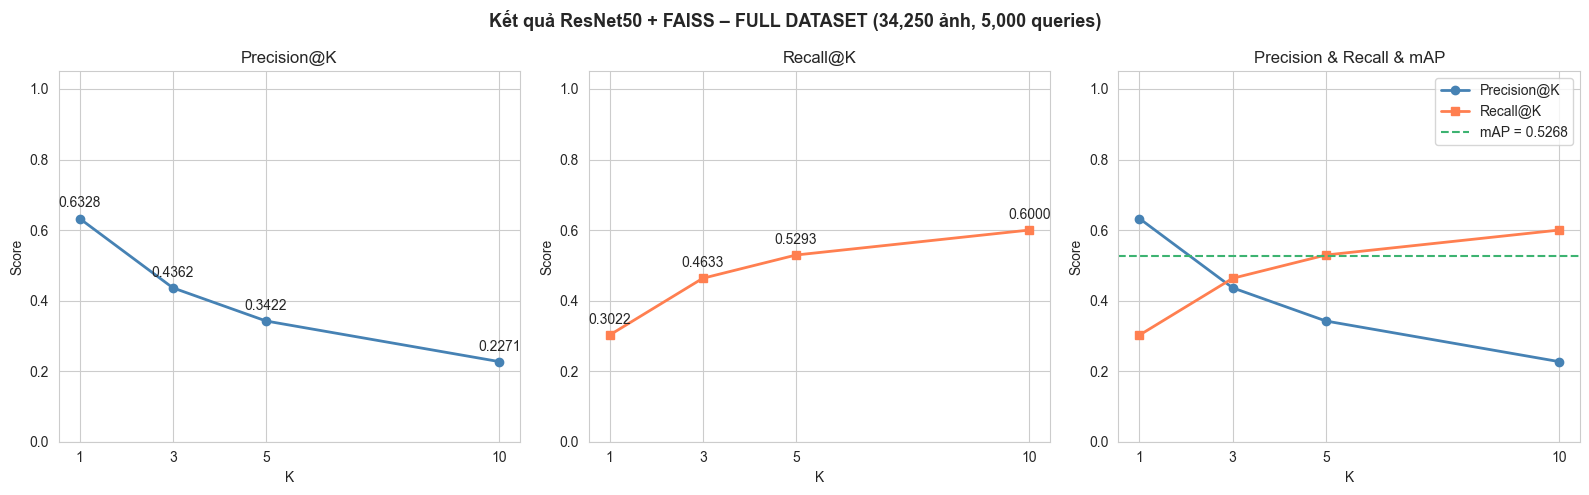


╔══ BẢNG METRIC – FULL DATASET ════════════════════════╗
     K   Precision@K    Recall@K
  ────────────────────────────────
     1        0.6328      0.3022
     3        0.4362      0.4633
     5        0.3422      0.5293
    10        0.2271      0.6000
  ────────────────────────────────
   mAP        0.5268
╚═══════════════════════════════════════════════════════╝


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Kết quả ResNet50 + FAISS – FULL DATASET ({len(candidate_df):,} ảnh, {len(query_idxs):,} queries)',
    fontsize=13, fontweight='bold'
)

k_vals = metrics_df['K'].tolist()

# Precision@K
axes[0].plot(k_vals, metrics_df['Precision@K'], marker='o', color='steelblue', linewidth=2)
for x, y in zip(k_vals, metrics_df['Precision@K']):
    axes[0].annotate(f'{y:.4f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center')
axes[0].set_title('Precision@K'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Score')
axes[0].set_xticks(k_vals); axes[0].set_ylim(0, 1.05)

# Recall@K
axes[1].plot(k_vals, metrics_df['Recall@K'], marker='s', color='coral', linewidth=2)
for x, y in zip(k_vals, metrics_df['Recall@K']):
    axes[1].annotate(f'{y:.4f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center')
axes[1].set_title('Recall@K'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')
axes[1].set_xticks(k_vals); axes[1].set_ylim(0, 1.05)

# Cả hai + mAP
axes[2].plot(k_vals, metrics_df['Precision@K'], marker='o', label='Precision@K', color='steelblue', linewidth=2)
axes[2].plot(k_vals, metrics_df['Recall@K'],    marker='s', label='Recall@K',    color='coral',     linewidth=2)
axes[2].axhline(y=mAP, color='mediumseagreen', linestyle='--', linewidth=1.5, label=f'mAP = {mAP:.4f}')
axes[2].set_title('Precision & Recall & mAP'); axes[2].set_xlabel('K'); axes[2].set_ylabel('Score')
axes[2].set_xticks(k_vals); axes[2].set_ylim(0, 1.05); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'metrics_full_dataset.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Bảng đẹp ────────────────────────────────────────────
print('\n╔══ BẢNG METRIC – FULL DATASET ════════════════════════╗')
print(f'  {"K":>4}  {"Precision@K":>12}  {"Recall@K":>10}')
print('  ' + '─'*32)
for _, row in metrics_df.iterrows():
    print(f'  {int(row["K"]):>4}  {row["Precision@K"]:>12.4f}  {row["Recall@K"]:>10.4f}')
print('  ' + '─'*32)
print(f'  {"mAP":>4}  {mAP:>12.4f}')
print('╚═══════════════════════════════════════════════════════╝')

---
## CELL 13: PHÂN TÍCH LỖI – QUERY CÓ AP THẤP NHẤT

In [15]:
all_pids = candidate_df['posting_id'].tolist()

# Gán AP vào từng query để tìm trường hợp xấu nhất
ap_per_query = detail_df['AP'].values

# Top 10 query có AP thấp nhất
worst_rank   = np.argsort(ap_per_query)[:10]
worst_queries = [
    {
        'query_idx' : int(query_idxs[r]),
        'posting_id': all_pids[query_idxs[r]],
        'gt_count'  : len(candidate_df.iloc[query_idxs[r]]['gt_matches']) - 1,
        'P@10'      : round(detail_df.iloc[r]['P@10'], 4),
        'AP'        : round(ap_per_query[r], 4),
    }
    for r in worst_rank
]

worst_df = pd.DataFrame(worst_queries)
print('🔍 10 query có AP thấp nhất:')
print(worst_df.to_string(index=False))

🔍 10 query có AP thấp nhất:
 query_idx       posting_id  gt_count   P@10     AP
     33942 train_3022066759         1 0.0000 0.0000
     12663 train_1049819810         1 0.0000 0.0000
      2609 train_3337372942         1 0.0000 0.0000
      7758   train_51240575         1 0.0000 0.0000
     29503 train_4136780766         1 0.0000 0.0000
     13177  train_619666284         1 0.0000 0.0000
      4062 train_2138022471         3 0.0000 0.0000
      8971 train_1256952043         1 0.0000 0.0000
     22273 train_1574813540         7 0.0000 0.0000
      1263 train_1080913905         1 0.0000 0.0000


---
## CELL 14: VISUALIZE QUERY → TOP-5

── 2 QUERY TỐT NHẤT ─────────────────────────────────────


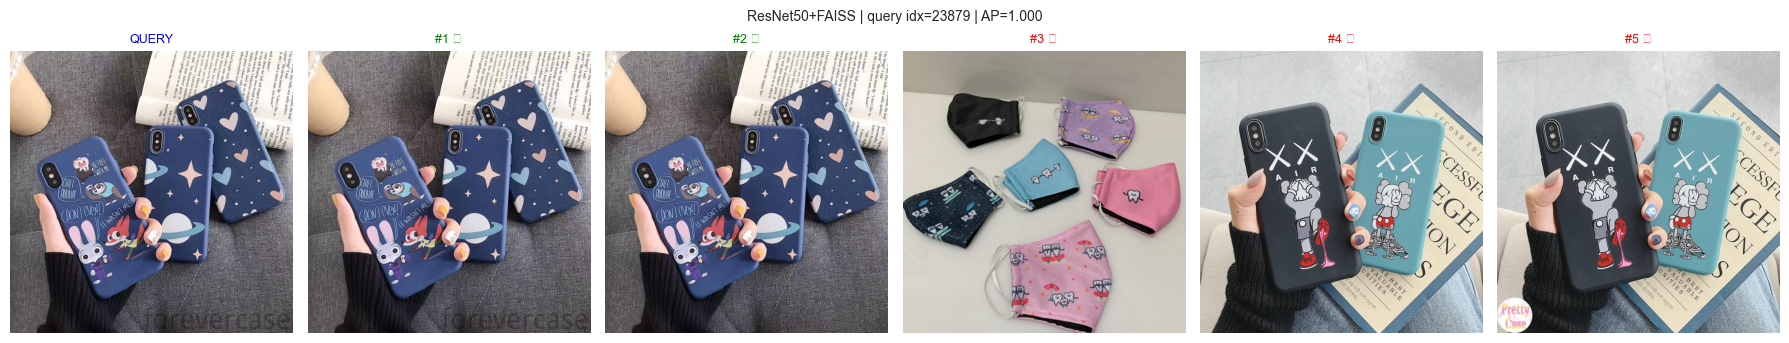

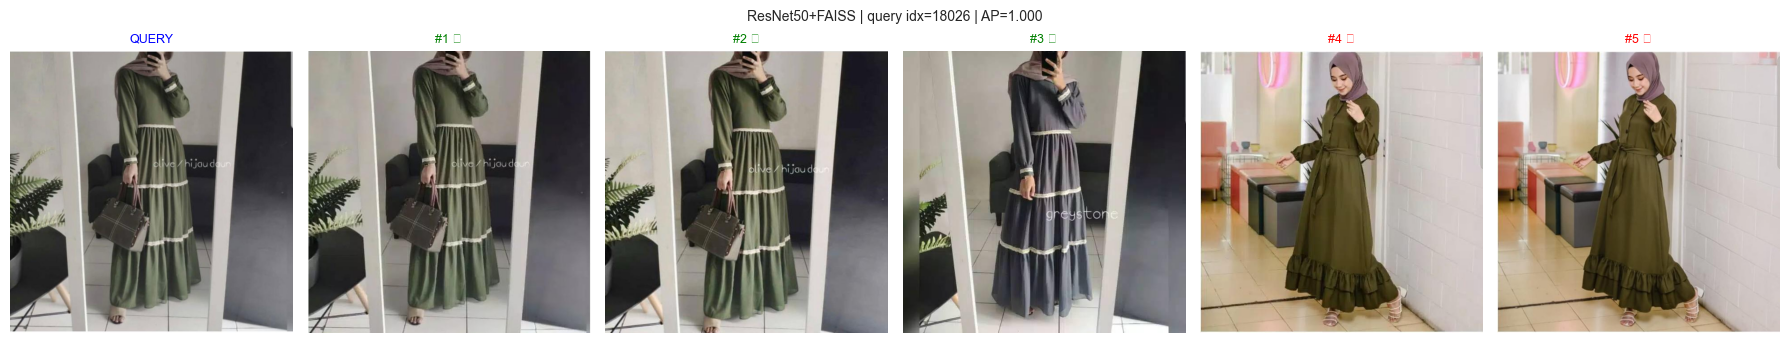

── 2 QUERY TỆ NHẤT ──────────────────────────────────────


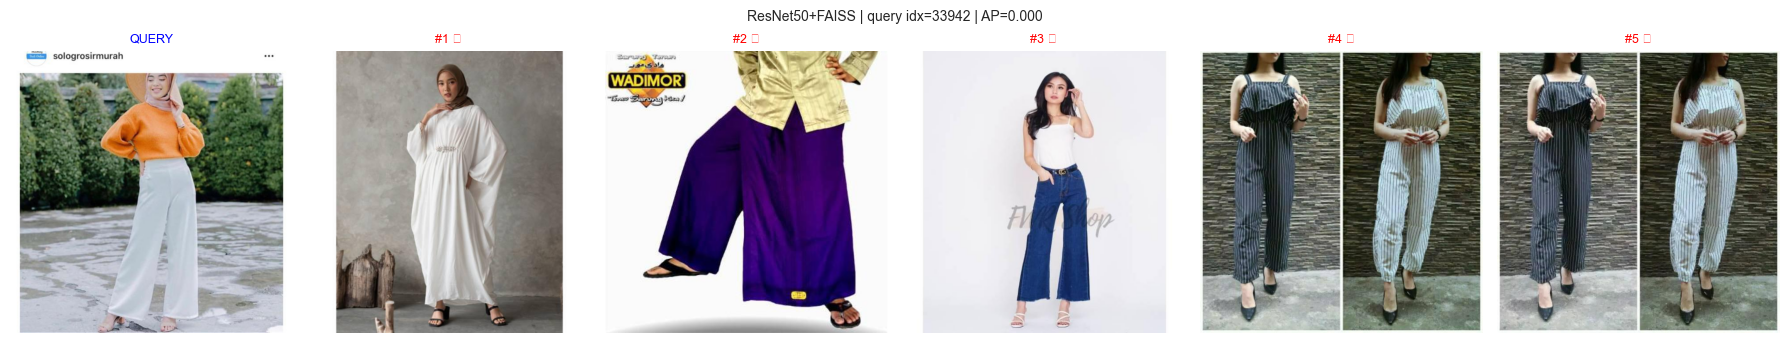

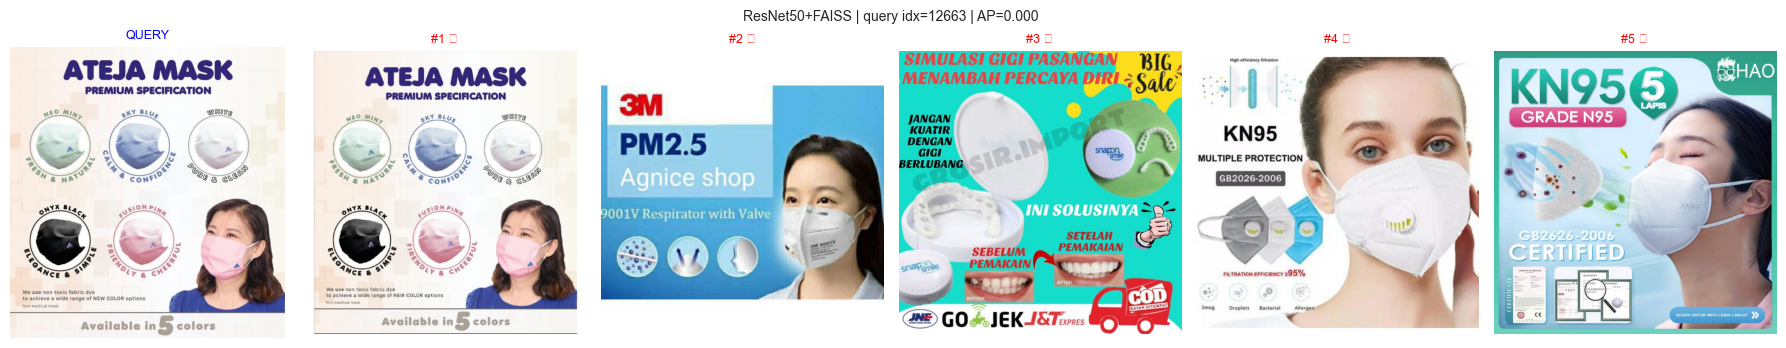

In [16]:
def show_query(candidate_df, query_idx, topk_row, k=5, title_prefix='ResNet50+FAISS'):
    all_pids = candidate_df['posting_id'].tolist()
    gt_set   = candidate_df.iloc[query_idx]['gt_matches'] - {all_pids[query_idx]}

    fig, axes = plt.subplots(1, k+1, figsize=(3*(k+1), 3.5))
    fig.suptitle(
        f'{title_prefix} | query idx={query_idx} | '
        f'AP={average_precision([all_pids[r] for r in topk_row[:k]], gt_set):.3f}',
        fontsize=10
    )

    q_img = Image.open(candidate_df.iloc[query_idx]['image_path']).convert('RGB')
    axes[0].imshow(q_img); axes[0].set_title('QUERY', color='blue', fontsize=9); axes[0].axis('off')

    for i, ridx in enumerate(topk_row[:k]):
        r_img = Image.open(candidate_df.iloc[ridx]['image_path']).convert('RGB')
        hit   = all_pids[ridx] in gt_set
        axes[i+1].imshow(r_img)
        axes[i+1].set_title(f'#{i+1} {"✓" if hit else "✗"}', color='green' if hit else 'red', fontsize=9)
        axes[i+1].axis('off')

    plt.tight_layout(); plt.show()


# Hiển thị: 2 query tốt nhất + 2 tệ nhất
best_rank  = np.argsort(ap_per_query)[::-1][:2]
worst_rank2 = np.argsort(ap_per_query)[:2]

print('── 2 QUERY TỐT NHẤT ─────────────────────────────────────')
for r in best_rank:
    show_query(candidate_df, int(query_idxs[r]), topk_ids[r])

print('── 2 QUERY TỆ NHẤT ──────────────────────────────────────')
for r in worst_rank2:
    show_query(candidate_df, int(query_idxs[r]), topk_ids[r])

---
## CELL 15: LƯU KẾT QUẢ & NHẬN XÉT

In [17]:
# ── Lưu file ──────────────────────────────────────────────
metrics_df['mAP'] = mAP
metrics_df.to_csv(os.path.join(RESULTS, 'metrics_full_resnet50.csv'), index=False)
detail_df.to_csv(os.path.join(RESULTS,  'detail_full_resnet50.csv'),  index=False)
np.save(os.path.join(PROCESSED, 'query_idxs_full.npy'),    query_idxs)
np.save(os.path.join(PROCESSED, 'topk_ids_full.npy'),      topk_ids)
print('✅ Đã lưu tất cả kết quả vào results/ và data/processed/')

# ── Nhận xét ──────────────────────────────────────────────
p1  = metrics_df.loc[metrics_df['K']==1,  'Precision@K'].values[0]
p5  = metrics_df.loc[metrics_df['K']==5,  'Precision@K'].values[0]
r5  = metrics_df.loc[metrics_df['K']==5,  'Recall@K'].values[0]
r10 = metrics_df.loc[metrics_df['K']==10, 'Recall@K'].values[0]

print('\n' + '='*62)
print('  NHẬN XÉT KẾT QUẢ – FULL DATASET')
print('  Mô hình : ResNet50 pretrained ImageNet + FAISS IndexFlatIP')
print(f'  Dataset : {len(candidate_df):,} ảnh | {candidate_df["label_group"].nunique():,} nhóm')
print(f'  Queries : {len(query_idxs):,} (ngẫu nhiên, seed=42)')
print('='*62)
print(f"""
[1] Precision@1 = {p1:.4f}
    → {p1*100:.1f}% query, ảnh Top-1 trả về đúng nhóm sản phẩm.

[2] Precision@5 = {p5:.4f}
    → Trong top-5, trung bình {p5*100:.1f}% ảnh thuộc đúng nhóm.
    → Precision giảm khi K tăng vì pool ảnh lớn hơn.

[3] Recall@5  = {r5:.4f}  |  Recall@10 = {r10:.4f}
    → Hệ thống tìm được {r5*100:.1f}% ảnh liên quan trong top-5.
    → Recall tăng dần khi mở rộng K – hành vi bình thường.

[4] mAP = {mAP:.4f}
    → Đây là mốc chuẩn để so sánh với Tuần 3:
       CLIP, FAISS+ResNet50, Image+Text kết hợp.

[5] Lý do dùng FAISS thay brute-force:
    - Brute-force cosine trên {len(candidate_df):,} ảnh × {len(query_idxs):,} query
      tốn O(N×Q×d) = O({len(candidate_df)*len(query_idxs)*EMBED_DIM:,.0f}) phép tính.
    - FAISS IndexFlatIP (C++/BLAS) nhanh hơn sklearn ~10-20×
      và hỗ trợ GPU.
    ⚠️  FAISS CHỈ TĂNG TỐC, KHÔNG THAY ĐỔI mAP.
       Kết quả với brute-force cosine sẽ GIỐNG HỆT (exact search).
""")
print('='*62)

✅ Đã lưu tất cả kết quả vào results/ và data/processed/

  NHẬN XÉT KẾT QUẢ – FULL DATASET
  Mô hình : ResNet50 pretrained ImageNet + FAISS IndexFlatIP
  Dataset : 34,250 ảnh | 11,014 nhóm
  Queries : 5,000 (ngẫu nhiên, seed=42)

[1] Precision@1 = 0.6328
    → 63.3% query, ảnh Top-1 trả về đúng nhóm sản phẩm.

[2] Precision@5 = 0.3422
    → Trong top-5, trung bình 34.2% ảnh thuộc đúng nhóm.
    → Precision giảm khi K tăng vì pool ảnh lớn hơn.

[3] Recall@5  = 0.5293  |  Recall@10 = 0.6000
    → Hệ thống tìm được 52.9% ảnh liên quan trong top-5.
    → Recall tăng dần khi mở rộng K – hành vi bình thường.

[4] mAP = 0.5268
    → Đây là mốc chuẩn để so sánh với Tuần 3:
       CLIP, FAISS+ResNet50, Image+Text kết hợp.

[5] Lý do dùng FAISS thay brute-force:
    - Brute-force cosine trên 34,250 ảnh × 5,000 query
      tốn O(N×Q×d) = O(350,720,000,000) phép tính.
    - FAISS IndexFlatIP (C++/BLAS) nhanh hơn sklearn ~10-20×
      và hỗ trợ GPU.
    ⚠️  FAISS CHỈ TĂNG TỐC, KHÔNG THAY ĐỔI mAP.
 